In [1]:
import os
import pickle
import h5py
import pywt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from matplotlib import animation
from scipy.signal import correlate2d
from scipy.stats import entropy
from IPython.display import HTML
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
H = 0.4                                              # 0.4 or 0.7 or 0.9
type_stimuli = "original"                            # 'extended' or 'original'
wbt = 'db2'                                          # 'db2' or 'haar'
review_axis = [0]                                    # [0] or [0,1,2]
if 1 in review_axis:
    level = 4
elif wbt == "haar":
    level = 9
elif wbt == "db2":
    level = 8

In [3]:
if H == 0.4:
    n_in = 1; n_fin = 11; n_event=2
if H == 0.7:
    n_in = 11; n_fin = 21; n_event=12
if H == 0.9:
    n_in = 21; n_fin = 31; n_event=22

if n_event <= 10:
    archivo_estimulo = 'ball_info04.pkl'
elif n_event <21:
    archivo_estimulo = 'ball_info07.pkl'
elif n_event > 20:
    archivo_estimulo = 'ball_info.pkl'

with open("../data/2D_stimuli_responses/"+archivo_estimulo, 'rb') as f:
    ball_info = pickle.load(f)

print(ball_info)

label = np.linspace(0,1199,5030)

def floor(x):
    return np.floor(x)

vectorized_floor = np.vectorize(floor)
label = vectorized_floor(label)
label = [int(i) for i in label]

def gaussian_2d(mean, std_dev, grid_size=100, xrange=[0,420], yrange=[0,420]):
    mu_x, mu_y = mean
    sigma_x, sigma_y = std_dev

    # Define x and y ranges
    if xrange is None:
        xrange = (mu_x - 3 * sigma_x, mu_x + 3 * sigma_x)
    if yrange is None:
        yrange = (mu_y - 3 * sigma_y, mu_y + 3 * sigma_y)

    x = np.linspace(*xrange, grid_size)
    y = np.linspace(*yrange, grid_size)
    X, Y = np.meshgrid(x, y)

    G = (1 / (2 * np.pi * sigma_x * sigma_y)) * \
        np.exp(-((X - mu_x) ** 2 / (2 * sigma_x ** 2) + (Y - mu_y) ** 2 / (2 * sigma_y ** 2)))

    return X, Y, G

gaussian_stimuli = []
for frame in range(len(ball_info)):
    mean = ball_info[frame][0]
    std_dev = ((1/2)*ball_info[frame][1],(1/2)*ball_info[frame][2])
    X, Y, G = gaussian_2d(mean, std_dev, grid_size=16)
    gaussian_stimuli.append(G)

stimuli_3d_label = np.zeros((1006,16,16))
index = [i for i in range(0,5030,5)]
for i in range(1006):
    stimuli_3d_label[i] = gaussian_stimuli[label[index[i]]] * 3000

[[(215, 215), 30, 50], [(216, 209), 30, 50], [(218, 217), 30, 50], [(203, 217), 30, 50], [(193, 220), 30, 50], [(185, 223), 30, 50], [(181, 215), 30, 50], [(177, 217), 30, 50], [(177, 231), 30, 50], [(181, 231), 30, 50], [(172, 240), 30, 50], [(161, 243), 30, 50], [(150, 249), 30, 50], [(147, 247), 30, 50], [(147, 249), 30, 50], [(135, 247), 30, 50], [(145, 247), 30, 50], [(137, 253), 30, 50], [(129, 251), 30, 50], [(125, 263), 30, 50], [(117, 265), 30, 50], [(109, 263), 30, 50], [(113, 257), 30, 50], [(113, 257), 30, 50], [(111, 259), 30, 50], [(111, 255), 30, 50], [(105, 255), 30, 50], [(111, 251), 30, 50], [(107, 259), 30, 50], [(95, 252), 30, 50], [(83, 243), 30, 50], [(78, 247), 30, 50], [(79, 255), 30, 50], [(77, 259), 30, 50], [(80, 255), 30, 50], [(85, 251), 30, 50], [(82, 251), 30, 50], [(87, 247), 30, 50], [(81, 241), 30, 50], [(95, 251), 30, 50], [(88, 253), 30, 50], [(73, 253), 30, 50], [(73, 253), 30, 50], [(70, 253), 30, 50], [(57, 264), 30, 50], [(51, 269), 30, 50], [(47

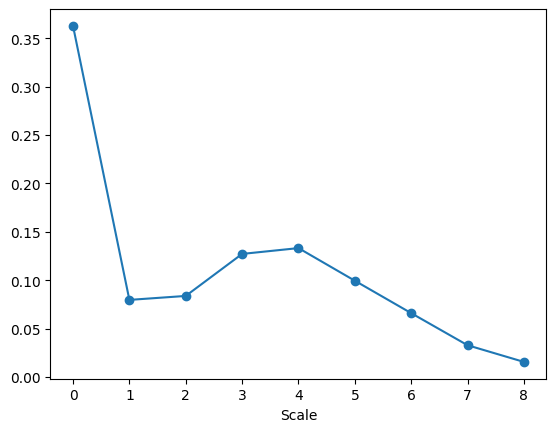

In [4]:
if type_stimuli != 'extended':
    coeffs = pywt.wavedecn(np.array(gaussian_stimuli), wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")
else:
    coeffs = pywt.wavedecn(stimuli_3d_label, wavelet=wbt,axes=review_axis,level=level)
    approx = coeffs[0]

    total_energy = np.sum(np.square(approx))
    details = [np.sum(np.square(approx))]  # start with approximation energy

    for level_dict in coeffs[1:]:
        level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
        total_energy += level_energy
        details.append(level_energy)

    # Normalize energy contributions
    proportions_stimuli = [e / total_energy for e in details]
    plt.plot(proportions_stimuli,marker="o")
    plt.xlabel("Scale")

## Pure response analysis

In [5]:
rep_results = {}
for n_e in range(n_in,n_fin):
    with open(f'../data/2D_stimuli_responses/{n_e}frames_5.pkl', 'rb') as f:
        videos_by_group = pickle.load(f)
    rep_results[n_e] = videos_by_group

averaged = {}

for key, values in videos_by_group.items():
    new_values = []
    for i in range(len(values)):
        if not (key == 'WT_6m' and i==1):
            ind_average = np.zeros((1006,16,16))
            for j in range(n_in,n_fin):
                ind_average += np.array(rep_results[j][key][i])
            ind_average = ind_average/10
            new_values.append(ind_average)
    averaged[key] = new_values

videos_by_group = averaged

def threshold_coeffs(coeffs, threshold):
    thresholded_coeffs = [coeffs[0]]  # Approximation coeffs at level 0 (do not threshold)

    for detail_level in coeffs[1:]:
        thresholded_level = {}
        for key, arr in detail_level.items():
            thresholded_arr = np.where(np.abs(arr) < threshold, 0, arr)
            thresholded_level[key] = thresholded_arr
        thresholded_coeffs.append(thresholded_level)

    return thresholded_coeffs


filtered_data = {}
for group_name, videos in videos_by_group.items():
    subframes = videos
    for i in range(len(videos)):
        coeffs = pywt.wavedecn(np.array(videos[i]), wavelet='db2')
        threshold = 0.01
        thresholded_coeffs = threshold_coeffs(coeffs, threshold)
        subframes[i] = pywt.waverecn(thresholded_coeffs, wavelet='db2')
        # ani = anim4(subframes[0], subframes[1], subframes[2], subframes[3], name=group_name)
        # display(HTML(ani.to_jshtml()))
    filtered_data[group_name] = subframes

correlated_denoised_videos = {}
for group_name in videos_by_group.keys():
    corr_videos = []
    for individual in videos_by_group[group_name]:
        reconstructed_video = individual
        new_video = np.multiply(np.abs(reconstructed_video),stimuli_3d_label)
        corr_videos.append(new_video)
    correlated_denoised_videos[group_name] = corr_videos

types = []
mean = []
fq = [] # first quartile
lq = []#  last quartile
sd = []
normas = []
proportion = []
outer_info = []
for group_name, videos in correlated_denoised_videos.items():
    for i in range(len(videos)):
        types.append(group_name)
        mean.append(np.mean(videos[i],axis=(1,2)))
        fq.append(np.percentile(np.abs(videos[i]),75,axis=(1,2)))
        lq.append(np.percentile(np.abs(videos[i]),90,axis=(1,2)))
        sd.append(np.std(videos[i],axis=(1,2)))
        pos = [[int(ball_info[label[frame]][0][0] /(420/16)),int(ball_info[label[frame]][0][1] /(420/16))] for frame in range(len(videos[i]))]
        norm_video=[]
        video_outer_frame = []
        frame_proportions = []
        for j in range(len(videos[i])):
            inner_frame = videos_by_group[group_name][i][j,pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4].copy()
            frame_proportions.append(np.linalg.norm(inner_frame,ord='fro'))#/np.linalg.norm(videos_by_group[group_name][i][j],ord='fro')
            outer_frame = videos_by_group[group_name][i][j].copy()
            semi_array_dim = (max(pos[j][0]-4,0),min(pos[j][0]+4,16),max(pos[j][1]-4,0),min(pos[j][1]+4,16))
            #outer_frame[semi_array_dim[0]:semi_array_dim[1]+1,semi_array_dim[2]:semi_array_dim[3]+1] = np.zeros((semi_array_dim[1]-semi_array_dim[0]+1,semi_array_dim[3]-semi_array_dim[2]+1)).copy()
            outer_frame[pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4] = np.zeros((outer_frame[pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4]).shape).copy()
            video_outer_frame.append(np.linalg.norm(outer_frame,ord='fro'))#/np.linalg.norm(videos_by_group[group_name][i][j],ord='fro')
            norm_video.append(np.linalg.norm(videos[i][j],ord='fro'))#,pos[j][0]-4:pos[j][0]+4,pos[j][1]-4:pos[j][1]+4
        coeffs = pywt.wavedecn(videos[i], wavelet=wbt,axes=review_axis,level=level)
        approx = coeffs[0]

        total_energy = np.sum(np.square(approx))
        details = [np.sum(np.square(approx))]  # start with approximation energy

        for level_dict in coeffs[1:]:
            level_energy = sum(np.sum(np.square(arr)) for arr in level_dict.values())
            total_energy += level_energy
            details.append(level_energy)

        # Normalize energy contributions
        proportions = [e / total_energy for e in details]
        normas.append(norm_video)
        outer_info.append(video_outer_frame)
        proportion.append(proportions)
features = {"type":types,"mean":mean,"75":fq,"90":lq,"sd":sd,"norm":normas,"inf_ratio":proportion,'outer_info' : outer_info}
summary = pd.DataFrame(features)
df = summary.copy()
df['K_L div'] = df['inf_ratio'].apply(lambda x: entropy(proportions_stimuli,x))

In [6]:
wavelet_prop = df[['type','inf_ratio','K_L div']].copy()
wavelet_prop['entropy'] = wavelet_prop['inf_ratio'].apply(entropy)
wavelet_prop['energy'] = wavelet_prop['inf_ratio'].apply(lambda x: x[3])

def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

wavelet_prop['age'] = wavelet_prop['type'].apply(age)
wavelet_prop['condition'] = wavelet_prop['type'].apply(condition)
wavelet_prop

,type,inf_ratio,K_L div,entropy,energy,age,condition
0,WT_3m,"[0.06508732098797958, 0.05458355341198266, 0.1...",0.445987,2.085394,0.103701,young,Wild-Type
1,WT_3m,"[0.06050515026532752, 0.06432375919002477, 0.0...",0.447612,2.067904,0.127809,young,Wild-Type
2,WT_3m,"[0.08033483064689473, 0.0677990857087067, 0.09...",0.370642,2.081117,0.116814,young,Wild-Type
3,WT_3m,"[0.08348413423813464, 0.0690811808973301, 0.08...",0.346026,2.105124,0.142656,young,Wild-Type
4,WT_3m,"[0.07316787260059594, 0.0599935633339854, 0.10...",0.382556,2.075248,0.138468,young,Wild-Type
5,WT_3m,"[0.07309299691894786, 0.059053329423626975, 0....",0.397321,2.076329,0.136992,young,Wild-Type
6,WT_3m,"[0.0786045118256488, 0.06217378941738223, 0.08...",0.369165,2.087977,0.125890,young,Wild-Type
7,WT_3m,"[0.10035819043046781, 0.06983834790565092, 0.0...",0.292233,2.108800,0.127709,young,Wild-Type
8,WT_6m,"[0.07098025238935678, 0.06455924766781311, 0.1...",0.394776,2.081904,0.124461,old,Wild-Type
9,WT_6m,"[0.06997989501744852, 0.05864753218287312, 0.0...",0.405763,2.060775,0.148043,old,Wild-Type


In [7]:
from utils import experiment_based_classification

print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["energy",'age']],"age")
print("== wavelet - cond==")
experiment_based_classification(wavelet_prop[["energy",'condition']],"condition")
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["entropy",'age']],'age')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["entropy",'condition']],'condition')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["K_L div",'age']],'age')
print("== wavelet - age==")
experiment_based_classification(wavelet_prop[["K_L div",'condition']],'condition')

== wavelet - age==


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 63.33%
== wavelet - cond==
LOOCV Accuracy 0: 50.00%
== wavelet - age==
LOOCV Accuracy 0: 70.00%
== wavelet - age==
LOOCV Accuracy 0: 50.00%
== wavelet - age==
LOOCV Accuracy 0: 56.67%
== wavelet - age==
LOOCV Accuracy 0: 43.33%


{'0': 0.43333333333333335}